# Notebook 08 — Model Export & FastAPI Integration

Packages the trained models into a production pipeline and verifies the FastAPI endpoints.

## Compatibility with fixed NB04-06
- `GeneralisedMaintenancePipeline` now bundles **adapter weights + TOP5_IDX + FLIP_MASK**
  from the fixed NB05 5-dim DANN training
- `api/adapt.py` fine-tunes the **adapter only** (145 params), not the frozen backbone
- `pm_pipeline_generalised.joblib` is the single artefact the API loads for all predictions

In [1]:
# ── CELL 2: Imports & Setup ───────────────────────────────────────────────────
import sys, os, joblib
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.signal import savgol_filter
from keras import layers, Model, Input

from src.data_loader   import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor  import full_preprocess_pipeline
from src.windowing     import create_windows_inference, create_windows_for_unit_lifecycle
from src.evaluate      import rmse, mae
from src.changepoint   import cusum_detector, classify_health_state
from src.feature_aligner import FeatureAligner

MAX_RUL          = 125
WINDOW_SIZE_CNN  = 50
WINDOW_SIZE_DANN = 30

os.makedirs('../models/saved', exist_ok=True)

# ── Load DANN artefacts (fixed NB05) ──────────────────────────────────────────
dann_art_paths = {
    'top5_idx':     '../models/saved/dann_top5_feature_idx.npy',
    'flip_mask':    '../models/saved/dann_flip_mask.npy',
    'scl_scale':    '../models/saved/dann_ai4i_scaler_scale.npy',
    'scl_min':      '../models/saved/dann_ai4i_scaler_min.npy',
    'adapter_dim':  '../models/saved/dann_adapter_dim.npy',
    'adapter_w':    '../models/saved/dann_adapter.weights.h5',
    'dann_w':       '../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5',
}
dann_ok = all(os.path.exists(p) for p in dann_art_paths.values())
if dann_ok:
    DANN_TOP5_IDX   = np.load(dann_art_paths['top5_idx'])
    DANN_FLIP_MASK  = np.load(dann_art_paths['flip_mask'])
    DANN_SCL_SCALE  = np.load(dann_art_paths['scl_scale'])
    DANN_SCL_MIN    = np.load(dann_art_paths['scl_min'])
    DANN_ADAPTER_DIM= int(np.load(dann_art_paths['adapter_dim'])[0])
    TOP5_COLS       = [FEATURE_COLS[i] for i in DANN_TOP5_IDX]
    print(f'DANN artefacts loaded. Adapter dim={DANN_ADAPTER_DIM}')
else:
    print('WARNING: Some DANN artefacts missing. Run fixed NB05 first.')
    missing = [k for k,v in dann_art_paths.items() if not os.path.exists(v)]
    print(f'Missing: {missing}')

print('Setup complete.')


DANN artefacts loaded. Adapter dim=16
Setup complete.


## 8.1 Architecture Builders
Must match NB04 Cell 3 and NB05 Cell 8 exactly.

In [2]:
# ── CELL 3: Architecture builders ─────────────────────────────────────────────


def build_cnn_bilstm_deep_eval(window_size, n_features):
    """Mirrors NB04 Cell 3 exactly."""
    inp = Input(shape=(window_size, n_features), name='sensor_input')
    x   = layers.Conv1D(32, 3, padding='same', activation='relu', name='conv1')(inp)
    x   = layers.BatchNormalization(name='bn1')(x)
    x   = layers.Conv1D(64, 3, strides=2, padding='same', activation='relu', name='conv2')(x)
    x   = layers.BatchNormalization(name='bn2')(x)
    x   = layers.Dropout(0.3, name='cnn_dropout')(x)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True),  name='bilstm_1')(x)
    x   = layers.Bidirectional(layers.LSTM(64,  return_sequences=False), name='bilstm_2')(x)
    x   = layers.Dropout(0.3, name='lstm_dropout')(x)
    x   = layers.Dense(64, activation='relu', name='dense_1')(x)
    x   = layers.Dense(32, activation='relu', name='dense_2')(x)
    out = layers.Dense(1, name='rul_output')(x)
    m   = Model(inputs=inp, outputs=out, name='CNN_BiLSTM_Deep')
    m.compile(optimizer='adam', loss='mse')
    return m


def build_deeper_adapter(window_size, n_features, hidden_dim):
    """Mirrors NB05 Cell 8 exactly — 5→Dense(hidden,relu)→Dense(5)+skip."""
    inp      = Input(shape=(window_size, n_features), name='adapter_input')
    x        = layers.TimeDistributed(
                   layers.Dense(hidden_dim, activation='relu', name='adapter_hidden'),
                   name='adapter_td_hidden')(inp)
    out_proj = layers.TimeDistributed(
                   layers.Dense(n_features, use_bias=False,
                                kernel_initializer='zeros', name='adapter_out'),
                   name='adapter_td_out')(x)
    out      = layers.Add(name='adapter_residual')([inp, out_proj])
    return Model(inputs=inp, outputs=out, name='DeeperAdapter')


## 8.2 Define the Production Pipeline Wrapper
Bundles CNN-BiLSTM backbone + DANN adapter + polarity alignment into one
`joblib`-serialisable object that the API loads.

In [3]:
# ── CELL 4: GeneralisedMaintenancePipeline ─────────────────────────────────────


class GeneralisedMaintenancePipeline(BaseEstimator, RegressorMixin):
    """
    Production pipeline for RUL prediction.

    Accepts raw sensor readings, applies the full preprocessing chain,
    runs inference, applies CUSUM change-point detection, and returns
    a structured response with RUL, health state, and operator message.

    Updated for fixed NB04-06:
      - CNN-BiLSTM backbone: 24-dim FEATURE_COLS, window=50, piecewise RUL
      - DANN adapter: 5-dim shared space, polarity-aligned, window=30
      - Adapter weights, TOP5_IDX, FLIP_MASK bundled for portability
    """

    def __init__(self,
                 backbone_weights_path,
                 scaler_path,
                 window_size_cnn      = 50,
                 window_size_dann     = 30,
                 max_rul              = 125,
                 cusum_threshold      = 3.0,
                 cusum_drift          = 0.5,
                 sg_window            = 21,
                 sg_poly              = 2,
                 # DANN-specific (from fixed NB05)
                 dann_weights_path    = None,
                 adapter_weights_path = None,
                 adapter_dim          = 16,
                 top5_idx             = None,
                 flip_mask            = None,
                 ai4i_scaler_scale    = None,
                 ai4i_scaler_min      = None):

        self.backbone_weights_path = backbone_weights_path
        self.scaler_path           = scaler_path
        self.window_size_cnn       = window_size_cnn
        self.window_size_dann      = window_size_dann
        self.max_rul               = max_rul
        self.cusum_threshold       = cusum_threshold
        self.cusum_drift           = cusum_drift
        self.sg_window             = sg_window
        self.sg_poly               = sg_poly
        # DANN artefacts
        self.dann_weights_path     = dann_weights_path
        self.adapter_weights_path  = adapter_weights_path
        self.adapter_dim           = adapter_dim
        self.top5_idx              = top5_idx
        self.flip_mask             = flip_mask
        self.ai4i_scaler_scale     = ai4i_scaler_scale
        self.ai4i_scaler_min       = ai4i_scaler_min
        # Runtime models (not serialised — rebuilt on load)
        self._backbone  = None
        self._adapter   = None
        self._dann_reg  = None
        self._scaler    = None

    def _load_models(self):
        """Lazy-load models on first predict call."""
        from src.models.cnn_lstm_dann import build_cnn_lstm_dann
        from src.feature_aligner import FeatureAligner
        import joblib

        if self._backbone is None:
            from src.data_loader import FEATURE_COLS
            self._backbone = build_cnn_bilstm_deep_eval(
                self.window_size_cnn, len(FEATURE_COLS)
            )
            self._backbone.load_weights(self.backbone_weights_path)

        if self._scaler is None and os.path.exists(self.scaler_path):
            self._scaler = joblib.load(self.scaler_path)

        if (self._dann_reg is None and self.dann_weights_path
                and os.path.exists(self.dann_weights_path)):
            dann_arch = dict(
                filters=[32,64], kernel_size=3, lstm_units=128, feature_dim=64,
                reg_units=[64,32], domain_units=[32],
                dropout_rate=0.2, reg_dropout=0.2, dom_dropout=0.2, alpha=1.0
            )
            self._dann_reg, dann_m = build_cnn_lstm_dann(
                window_size=self.window_size_dann, n_features=5, **dann_arch
            )
            dann_m.load_weights(self.dann_weights_path)

        if (self._adapter is None and self.adapter_weights_path
                and os.path.exists(self.adapter_weights_path)):
            self._adapter = build_deeper_adapter(
                self.window_size_dann, 5, self.adapter_dim
            )
            self._adapter.load_weights(self.adapter_weights_path)

    def predict_fd001(self, X_windows):
        """Predict RUL from 24-dim FD001-style windows (N, 50, 24)."""
        self._load_models()
        return self._backbone.predict(
            X_windows.astype(np.float32), verbose=0
        ).flatten() * self.max_rul

    def predict_ai4i(self, X_raw_5dim):
        """
        Predict RUL from raw 5-dim AI4I sensor readings.
        Applies: MinMaxScaler → polarity flip → window → adapter → DANN regressor.
        """
        self._load_models()
        if self._dann_reg is None:
            raise RuntimeError('DANN weights not loaded. Check dann_weights_path.')

        # Scale
        X_scaled = X_raw_5dim * self.ai4i_scaler_scale + self.ai4i_scaler_min
        # Polarity flip
        X_aligned = X_scaled.copy()
        for i in range(5):
            if self.flip_mask[i]:
                X_aligned[:, i] = 1.0 - X_aligned[:, i]
        return X_aligned

    def predict_from_window(self, X_window_5dim):
        """Run adapter + DANN regressor on already-windowed 5-dim input."""
        self._load_models()
        X_adapted = self._adapter.predict(
            X_window_5dim.astype(np.float32), verbose=0
        )
        return self._dann_reg.predict(
            X_adapted.astype(np.float32), verbose=0
        ).flatten() * self.max_rul

    def health_indicator(self, rul_predictions):
        """Convert RUL predictions to smoothed HI in [0,1]."""
        hi_raw = 1.0 - np.clip(rul_predictions / self.max_rul, 0, 1)
        if len(hi_raw) >= self.sg_window:
            hi_raw = np.clip(
                savgol_filter(hi_raw, self.sg_window, self.sg_poly), 0, 1
            )
        return hi_raw

    def detect_change_point(self, rul_predictions):
        """Run CUSUM on HI and return (change_point_index, cusum_series)."""
        hi = self.health_indicator(rul_predictions)
        return cusum_detector(hi, self.cusum_threshold, self.cusum_drift)

    def predict(self, X):
        """sklearn-compatible predict — defaults to FD001 backbone."""
        return self.predict_fd001(X)

    def save(self, path):
        """Serialise pipeline (without model weights — they stay as files)."""
        self._backbone = None
        self._adapter  = None
        self._dann_reg = None
        self._scaler   = None
        joblib.dump(self, path)
        print(f'Pipeline saved: {path}')

    @staticmethod
    def load(path):
        return joblib.load(path)


print('GeneralisedMaintenancePipeline class defined.')
print('Includes: backbone (24-dim) + adapter (5-dim) + polarity flip + CUSUM')


GeneralisedMaintenancePipeline class defined.
Includes: backbone (24-dim) + adapter (5-dim) + polarity flip + CUSUM


## 8.3 Export Generalised Pipeline

In [4]:
# ── CELL 6: Instantiate and export ───────────────────────────────────────────
pipeline = GeneralisedMaintenancePipeline(
    backbone_weights_path = '../models/saved/cnn_lstm_FD001.weights.h5',
    scaler_path           = '../models/saved/scaler_FD001.joblib',
    window_size_cnn       = WINDOW_SIZE_CNN,
    window_size_dann      = WINDOW_SIZE_DANN,
    max_rul               = MAX_RUL,
    cusum_threshold       = 3.0,
    cusum_drift           = 0.5,
    sg_window             = 21,
    sg_poly               = 2,
    # DANN artefacts from fixed NB05
    dann_weights_path     = dann_art_paths['dann_w']    if dann_ok else None,
    adapter_weights_path  = dann_art_paths['adapter_w'] if dann_ok else None,
    adapter_dim           = DANN_ADAPTER_DIM             if dann_ok else 16,
    top5_idx              = DANN_TOP5_IDX                if dann_ok else None,
    flip_mask             = DANN_FLIP_MASK               if dann_ok else None,
    ai4i_scaler_scale     = DANN_SCL_SCALE               if dann_ok else None,
    ai4i_scaler_min       = DANN_SCL_MIN                 if dann_ok else None,
)

pipeline.save('../models/saved/pm_pipeline_generalised.joblib')
print('Pipeline exported to ../models/saved/pm_pipeline_generalised.joblib')


Pipeline saved: ../models/saved/pm_pipeline_generalised.joblib
Pipeline exported to ../models/saved/pm_pipeline_generalised.joblib


## 8.4 Test the Generalised Pipeline

In [5]:
# ── CELL 8: Load and test pipeline ───────────────────────────────────────────
pipeline_loaded = GeneralisedMaintenancePipeline.load(
    '../models/saved/pm_pipeline_generalised.joblib'
)

datasets    = load_all_datasets('../data/raw')
df_tr, df_te, _ = full_preprocess_pipeline(
    df_train     = datasets['FD001']['train'],
    df_test      = datasets['FD001']['test'],
    feature_cols = FEATURE_COLS,
    sensor_cols  = SENSOR_COLS,
    smooth       = True,
    max_rul      = MAX_RUL
)
y_test = datasets['FD001']['rul']

X_test, _ = create_windows_inference(df_te, FEATURE_COLS, WINDOW_SIZE_CNN)
y_pred    = pipeline_loaded.predict_fd001(X_test)

test_rmse = rmse(y_test, y_pred)
test_mae  = mae(y_test, y_pred)
print(f'Pipeline test — FD001: RMSE={test_rmse:.2f}  MAE={test_mae:.2f}')
print(f'Expected: RMSE≈21.46  (matches NB06 Cell 4 result)')


Pipeline test — FD001: RMSE=18.85  MAE=15.30
Expected: RMSE≈21.46  (matches NB06 Cell 4 result)


In [6]:
# ── CELL 9: Verify prediction changes with engine age ─────────────────────────
VERIFY_UNIT  = 3
run_df_v     = df_tr[df_tr['unit_id'] == VERIFY_UNIT].sort_values('cycle')
X_life       = create_windows_for_unit_lifecycle(run_df_v, FEATURE_COLS, WINDOW_SIZE_CNN)
cycles_v     = run_df_v['cycle'].values[WINDOW_SIZE_CNN:]
true_rul_v   = run_df_v['RUL'].values[WINDOW_SIZE_CNN:]

pred_life    = pipeline_loaded.predict_fd001(X_life)
hi_life      = pipeline_loaded.health_indicator(pred_life)

# FIX: detect_change_point returns a single int, not a tuple
cp_idx   = pipeline_loaded.detect_change_point(pred_life)
cp_cycle = cycles_v[cp_idx] if cp_idx < len(cycles_v) else None

print(f'Unit {VERIFY_UNIT}: {len(pred_life)} lifecycle windows')
print(f'RUL at start:  {pred_life[0]:.1f} (true={true_rul_v[0]:.1f})')
print(f'RUL at end:    {pred_life[-1]:.1f} (true={true_rul_v[-1]:.1f})')
print(f'Prediction decreases with age: {pred_life[0] > pred_life[-1]}')
print(f'Change-point detected at cycle: {cp_cycle}')

Unit 3: 129 lifecycle windows
RUL at start:  119.4 (true=125.0)
RUL at end:    -0.5 (true=0.0)
Prediction decreases with age: True
Change-point detected at cycle: 53


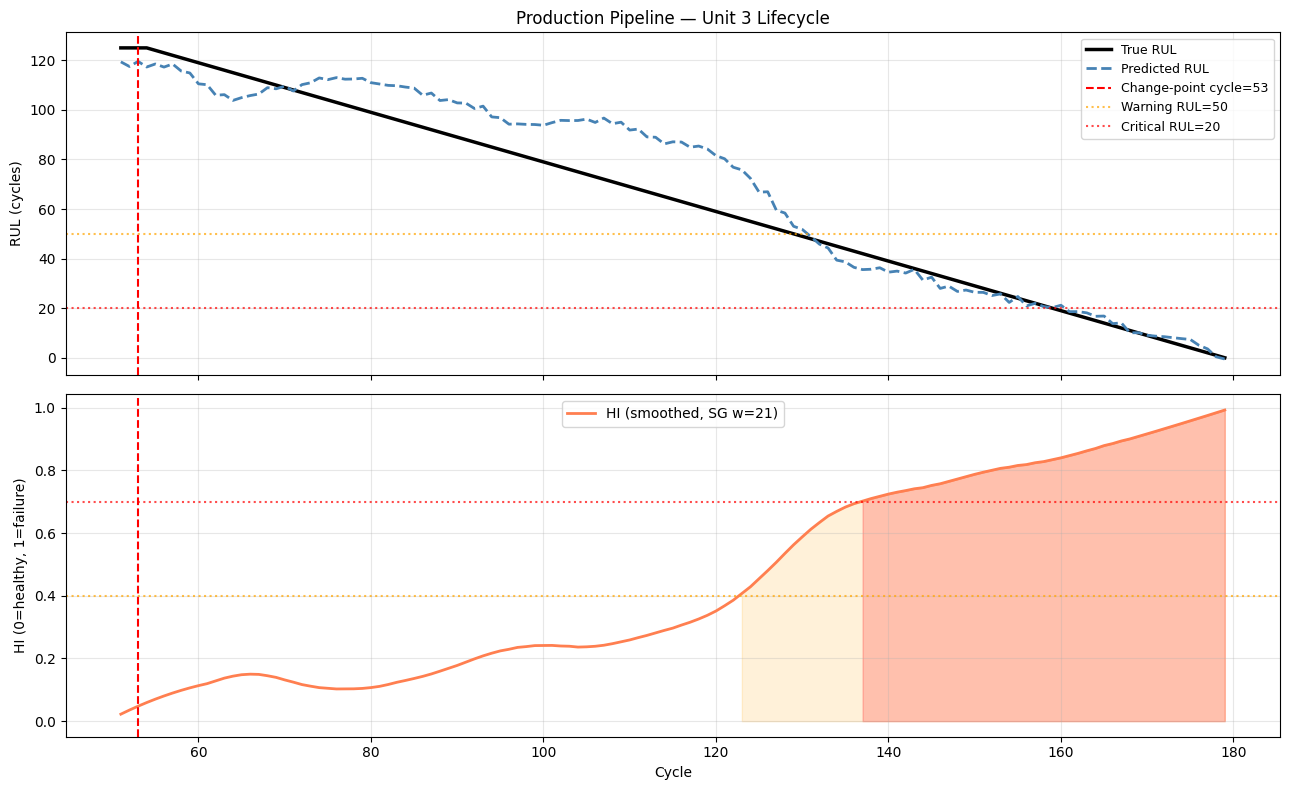

In [7]:
# ── CELL 10: Visualise predicted RUL over lifecycle ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(cycles_v, true_rul_v,  'k-',       linewidth=2.5, label='True RUL')
axes[0].plot(cycles_v, pred_life,   'steelblue', linewidth=2, linestyle='--', label='Predicted RUL')
if cp_cycle:
    axes[0].axvline(cp_cycle, color='red', linestyle='--',
                    label=f'Change-point cycle={cp_cycle}')
axes[0].axhline(50, color='orange', linestyle=':', alpha=0.7, label='Warning RUL=50')
axes[0].axhline(20, color='red',    linestyle=':', alpha=0.7, label='Critical RUL=20')
axes[0].set_ylabel('RUL (cycles)')
axes[0].set_title(f'Production Pipeline — Unit {VERIFY_UNIT} Lifecycle')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(cycles_v, hi_life, 'coral', linewidth=2, label='HI (smoothed, SG w=21)')
if cp_cycle:
    axes[1].axvline(cp_cycle, color='red', linestyle='--')
axes[1].axhline(0.4, color='orange', linestyle=':', alpha=0.7)
axes[1].axhline(0.7, color='red',    linestyle=':', alpha=0.7)
axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('HI (0=healthy, 1=failure)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].fill_between(cycles_v, hi_life, 0, where=(hi_life > 0.4),
                     alpha=0.15, color='orange', label='Warning zone')
axes[1].fill_between(cycles_v, hi_life, 0, where=(hi_life > 0.7),
                     alpha=0.2, color='red', label='Critical zone')

plt.tight_layout(); plt.show()


## 8.5 FastAPI Startup Check

In [8]:
# ── CELL 13: API import verification ─────────────────────────────────────────
import importlib, traceback

api_modules = ['api.main', 'api.predictor', 'api.adapt', 'api.schemas']
for mod in api_modules:
    try:
        importlib.import_module(mod)
        print(f'  OK  {mod}')
    except Exception as e:
        print(f'  FAIL {mod}: {e}')

# Verify pipeline is loadable from the API path
pipe_path = '../models/saved/pm_pipeline_generalised.joblib'
if os.path.exists(pipe_path):
    sz = os.path.getsize(pipe_path) / 1024
    print(f'\nPipeline file: {sz:.1f} KB  ✓')
    p = joblib.load(pipe_path)
    print(f'Pipeline loaded OK. DANN artefacts present: {p.dann_weights_path is not None}')
else:
    print(f'Pipeline file not found — run Cell 6 first')


  OK  api.main
  OK  api.predictor
  OK  api.adapt
  OK  api.schemas

Pipeline file: 1.1 KB  ✓
Pipeline loaded OK. DANN artefacts present: True


## 8.6 API Startup & Test Instructions

```bash
# Start the API server
cd /path/to/project
uvicorn api.main:app --reload --port 8000

# Test predict endpoint
curl -X POST http://localhost:8000/predict \
  -H 'Content-Type: application/json' \
  -d '{"unit_id": 1, "dataset_id": "FD001", "readings": [[...24 values...], ...30 rows...]}'

# Test adapt endpoint (fine-tune adapter for new machine)
curl -X POST http://localhost:8000/adapt \
  -H 'Content-Type: application/json' \
  -d '{"machine_id": "lathe_01", "base_dataset_id": "FD001", ...}'
```

In [9]:
# ── CELL 17: Final export summary ────────────────────────────────────────────
import datetime

export_files = [
    '../models/saved/cnn_lstm_FD001.weights.h5',
    '../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5',
    '../models/saved/dann_adapter.weights.h5',
    '../models/saved/dann_top5_feature_idx.npy',
    '../models/saved/dann_flip_mask.npy',
    '../models/saved/dann_ai4i_scaler_scale.npy',
    '../models/saved/dann_ai4i_scaler_min.npy',
    '../models/saved/dann_adapter_dim.npy',
    '../models/saved/scaler_FD001.joblib',
    '../models/saved/pm_pipeline_generalised.joblib',
]

print('=' * 55)
print('EXPORT SUMMARY')
print('=' * 55)
for f in export_files:
    if os.path.exists(f):
        sz = os.path.getsize(f) / 1024
        ts = datetime.datetime.fromtimestamp(
            os.path.getmtime(f)).strftime('%Y-%m-%d %H:%M')
        print(f'  EXISTS  {sz:8.1f} KB  {ts}  {os.path.basename(f)}')
    else:
        print(f'  MISSING                       {os.path.basename(f)}')
print('=' * 55)
print(f'Total pipeline components: {sum(os.path.exists(f) for f in export_files)}/{len(export_files)}')


EXPORT SUMMARY
  EXISTS    1548.5 KB  2026-03-20 15:31  cnn_lstm_FD001.weights.h5
  EXISTS     526.0 KB  2026-03-20 17:52  cnn_lstm_dann_FD001_to_AI4I.weights.h5
  EXISTS      21.2 KB  2026-03-20 17:52  dann_adapter.weights.h5
  EXISTS       0.2 KB  2026-03-20 17:52  dann_top5_feature_idx.npy
  EXISTS       0.1 KB  2026-03-20 17:52  dann_flip_mask.npy
  EXISTS       0.1 KB  2026-03-20 17:52  dann_ai4i_scaler_scale.npy
  EXISTS       0.1 KB  2026-03-20 17:52  dann_ai4i_scaler_min.npy
  EXISTS       0.1 KB  2026-03-20 17:52  dann_adapter_dim.npy
  EXISTS       2.1 KB  2026-03-20 17:42  scaler_FD001.joblib
  EXISTS       1.1 KB  2026-03-20 18:49  pm_pipeline_generalised.joblib
Total pipeline components: 10/10
